In [1]:
import numpy as np
import matplotlib.pyplot as plt

from plots import *
from src import (
    Transducer, phase_correct, moments,
    Phi_fock, Phi_coherent, fidelity,
    gkp_envelope, gkp_channel_params, gkp_infidelity,
)

# Enable SVG in Jupyter notebooks.
%config InlineBackend.figure_formats = ['svg']

# Microwave-optical transduction fidelity

## Parameters

In [2]:
kappa_a = 13.2      # Optical linewidth [2π * GHz]
kappa_b = 0.002     # Microwave linewidth [2π * GHz]
omega_b = 5.0       # Microwave frequency [2π * GHz]
Delta_a = 0.2       # Optical detuning [2π * GHz]

# Parametric coupling ratio from Eq. (24).
z = 1 / abs(1 - (omega_b/Delta_a)**2)

# Transduction and two-mode squeezing rates.
g_t = np.sqrt(kappa_a * kappa_b) / 2
g_s = z * g_t

# Transduction resonance condition.
Delta = omega_b

# Central transduction frequency
omega_c = omega_b

In [3]:
# External coupling fractions (all-external loss).
eta_a = 1.0
eta_b = 1.0

# Assemble the transducer.
transducer = Transducer(kappa_a, kappa_b, omega_b, Delta, eta_a, eta_b)

# Obtain noise moments.
S, L = transducer.channel(omega_c, g_t, g_s)
mu, nu, NdN, NN, comm = moments(S, L)

## Numerics

In [4]:
# Mean photon numbers.
n_fock = np.arange(1, 16)             # Number states (integer)
nbar_coh = np.linspace(1.0, 15, 61)   # Coherent states (continuous)
nbar_gkp = np.linspace(1.0, 15, 61)   # GKP states (continuous)

In [5]:
# Fock state fidelity.
F_fock = np.empty(len(n_fock))
for j, n in enumerate(n_fock):
    F_fock[j] = fidelity(lambda w: Phi_fock(w, n), mu, nu, NdN, NN, comm)

# Coherent state fidelity.
F_coh  = np.empty(len(nbar_coh))
for j, nbar in enumerate(nbar_coh):
    F_coh[j] = fidelity(lambda w: Phi_coherent(w, np.sqrt(nbar)), mu, nu, NdN, NN, comm)

In [6]:
# GKP average gate fidelity (App. F.2), same channel asymmetry z as above.
eta_gkp, delta_gkp, sigmaGp, sigmaGm = gkp_channel_params(kappa_a, kappa_b, omega_b, z, eta_a, eta_b)
F_gkp = 1 - np.array([gkp_infidelity(n, eta_gkp, delta_gkp, sigmaGp, sigmaGm) for n in nbar_gkp])


## Figure

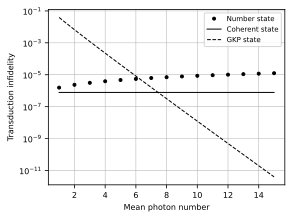

In [7]:
fig, axs = plt.subplots(
    nrows = 1,
    ncols = 1,
    figsize = (
        1.2 * FIG_SIZES['onecol'],
        0.9 * FIG_SIZES['onecol']
        ),
    sharey = True,
    )

label = fr'$\Delta_a/\omega_b = {Delta_a/omega_b:g}$'
axs.plot(n_fock, 1-F_fock, c='k', marker='o', ls='', label='Number state')
axs.plot(nbar_coh, 1-F_coh, c='k', label='Coherent state')
axs.plot(nbar_gkp, 1-F_gkp, c='k', ls='--', label='GKP state')

axs.semilogy()
axs.grid('both')
# axs.set_ylim(6e-7, 2e-5)
# axs.set_xlim(0, 15)

axs.set_xlabel('Mean photon number')
axs.set_ylabel('Transduction infidelity')
axs.legend(loc='upper right')

fig.tight_layout()
fig.savefig('fig/transduction.pdf', bbox_inches='tight')